## Análise de sentimento de avaliação de um e-commerce


In [1]:
!git clone https://github.com/alura-cursos/nlp_analise_sentimento.git

Cloning into 'nlp_analise_sentimento'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 186 (delta 24), reused 7 (delta 7), pack-reused 132 (from 1)
Receiving objects: 100% (186/186), 27.13 MiB | 15.17 MiB/s, done.
Resolving deltas: 100% (46/46), done.


In [2]:
!pip install unidecode


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 3.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk import tokenize
import seaborn as sns
import unidecode

In [4]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [5]:
df = pd.read_csv('nlp_analise_sentimento/Dados/dataset_avaliacoes.csv')
df.head(7)

,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo
5,13086,Comprei o produto e ñ tinha para entrega isso ...,1,negativo
6,117549,"o produto pode até ser bom ,mais só posso aval...",1,negativo


In [6]:
df.value_counts('sentimento')

,count
sentimento,
positivo,7890
negativo,7611


In [7]:
print('positiva')
df.avaliacao[df.sentimento == 'positivo'].head(3)

positiva


,avaliacao
0,"Esse smartphone superou minhas expectativas, r..."
3,"Atendeu minhas expectativas, só achei a luz ru..."
4,"Gostei muito, só achei que ficou a desejar a q..."


In [8]:
print('negativo')
df.avaliacao[2]

negativo


'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.'

### Exemplo bow

In [9]:
texto = ['Comprei esse produto aqui muito bom', 'Comprei esse produto que é ruim']
vec = CountVectorizer()
bow = vec.fit_transform(texto)
bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 11 stored elements and shape (2, 8)>

In [10]:
matrix_sparsa = pd.DataFrame.sparse.from_spmatrix(bow, columns=vec.get_feature_names_out())
matrix_sparsa

,aqui,bom,comprei,esse,muito,produto,que,ruim
0,1,1,1,1,1,1,0,0
1,0,0,1,1,0,1,1,1


Vamos primeiramente testar com os dados brutos sem pré-processamento de letras maiúsculas

Muitas colunas pesam computacionalmente

In [11]:
vec = CountVectorizer(lowercase=False, max_features=50)
bow = vec.fit_transform(df.avaliacao)
print(bow.shape)

(15501, 50)


In [12]:
matrix_sparsa = pd.DataFrame.sparse.from_spmatrix(bow, columns=vec.get_feature_names_out())
matrix_sparsa

,Não,Produto,ainda,antes,as,até,bem,bom,chegou,com,...,qualidade,que,recebi,recomendo,se,sem,tem,um,uma,veio
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,1,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
15497,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
15498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
15499,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
X_train, X_test, y_train, y_test = train_test_split(bow, df.sentimento, random_state=4978)

model = LogisticRegression()
model.fit(X_train, y_train)
acc = model.score(X_test, y_test)
print(f'Acurácia: {acc:.3f}')

Acurácia: 0.798


In [14]:
all_words = [texto for texto in df.avaliacao]
all_words = ' '.join([texto for texto in df.avaliacao])
all_words

Output hidden; open in https://colab.research.google.com to view.

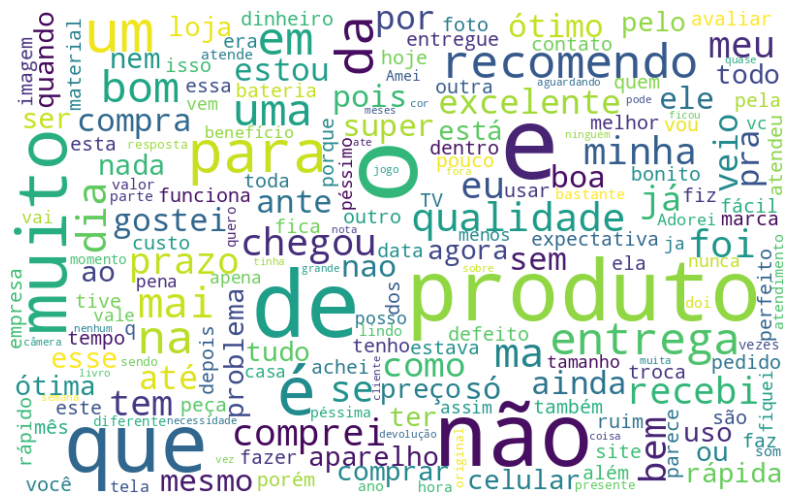

In [15]:
word_cloud = WordCloud(background_color='white', width=800,
                       height=500, max_font_size=110,
                       collocations=False).generate(all_words)
plt.figure(figsize=(10,8))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

0        Esse smartphone superou minhas expectativas, r...
3        Atendeu minhas expectativas, só achei a luz ru...
4        Gostei muito, só achei que ficou a desejar a q...
10       Melhor que esperado, cor maravilhosa! Recomend...
15       Um aparelho com uma ótima performance e um pre...
                               ...                        
15495    Gostei do produto, atendeu minhas necessidades...
15496    Bommm.mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...
15498    Muito simples de mexer, o manual explica direi...
15499    Produto muito bom, exatamente como na internet...
15500    É incrível como voce é abandonado dentro de su...
Name: avaliacao, Length: 7890, dtype: object


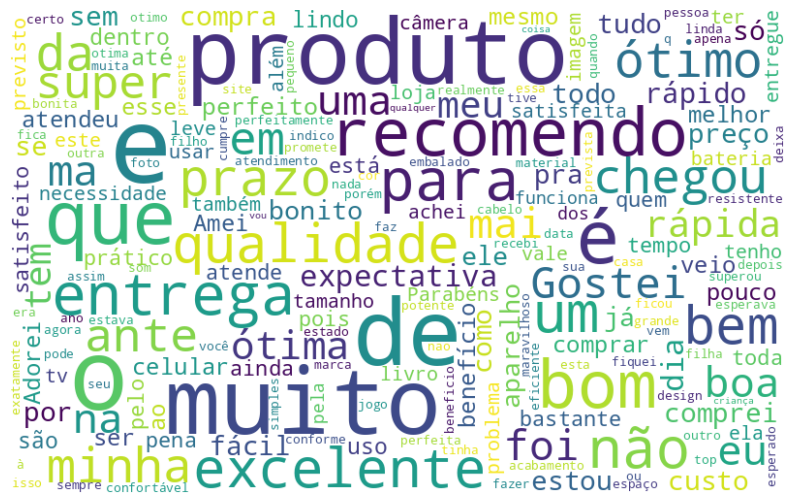

In [16]:
#palavras positivas

def nuvem_palavras(df, coluna_texto, sentimento):
  texto_sentimento = df.query(f"sentimento == '{sentimento}'")[coluna_texto]
  text_unido = ' '.join(texto_sentimento)
  word_cloud = WordCloud(background_color='white', width=800,
                       height=500, max_font_size=110,
                       collocations=False).generate(text_unido)

  print(texto_sentimento)
  plt.figure(figsize=(10,8))
  plt.imshow(word_cloud, interpolation='bilinear')
  plt.axis('off')
  plt.show()

nuvem_palavras(df, 'avaliacao', 'positivo')

1        o cheiro e muito desagradavel!! pra quem se in...
2        Eu fiz a compra a loja não entregou o produto,...
5        Comprei o produto e ñ tinha para entrega isso ...
6        o produto pode até ser bom ,mais só posso aval...
7        já enviei duas reclamações, mas não obtive res...
                               ...                        
15490    tv nao segura configuração. atendimento suport...
15492    Na hora de comprar nao diz qual é a altira e q...
15493    Eu queria muito esse produto mais faz dias que...
15494    QUANDO CLIQUEI NA PROMO ONDE ADQUIRI ESTE CELU...
15497    O produto seca o cabelo, mas tem que passar di...
Name: avaliacao, Length: 7611, dtype: object


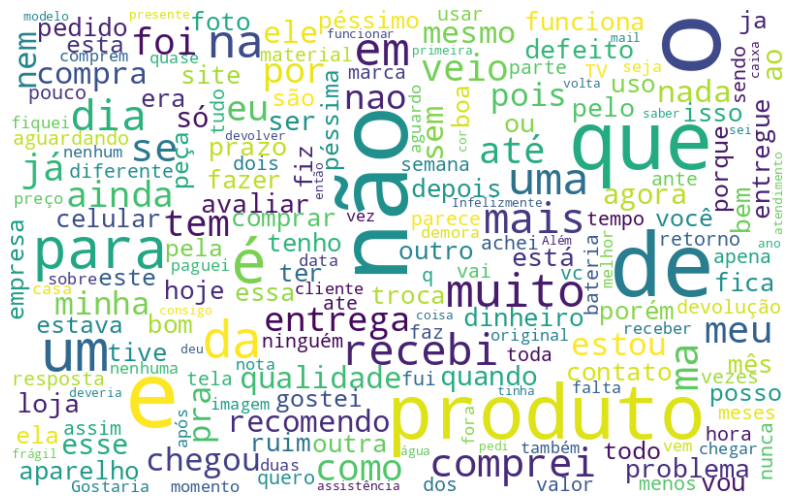

In [17]:
#palavras negativas

nuvem_palavras(df, 'avaliacao', 'negativo')

### Exemplo uso do nltk

In [18]:
frases = ['produto eh muito bom', 'produto eh ruim']

frequencia = nltk.FreqDist(frases)
frequencia

FreqDist({'produto eh muito bom': 1, 'produto eh ruim': 1})

In [19]:
frase = 'O produto eh excelente e a entrega foi rápida!'

token_espaco = tokenize.WhitespaceTokenizer()
token_frase = token_espaco.tokenize(frase)
token_frase

['O', 'produto', 'eh', 'excelente', 'e', 'a', 'entrega', 'foi', 'rápida!']

> **Uma vez que o texto é dividido em tokens, é possível:**

---


1. Calcular a frequência de palavras, o que ajuda a identificar os termos mais comuns e relevantes em um conjunto de dados.

2. Construir matrizes de representações numéricas do texto, como as famosas "Bag-of-Words" ou "TF-IDF" (que exploraremos mais adiante no curso), utilizadas para treinar modelos de Machine Learning.

3. Aplicar técnicas mais avançadas, como a análise de n-gramas, que consideram combinações de palavras em sequência para captar relações contextuais (também abordaremos esse tema no final do curso).

4. Além disso, a tokenização facilita o uso de modelos de linguagem mais recentes, como o BERT e o GPT, que trabalham com tokens de subpalavras, permitindo uma compreensão mais profunda de palavras raras ou compostas.

  Há diferentes abordagens de tokenização que podem ser usadas, dependendo do problema:

  Tokenização por palavras: Divide o texto em palavras individuais. É útil para análises onde o foco está no significado das palavras completas, como no nosso caso.

  Tokenização por subpalavras: Quebra palavras em partes menores, o que é particularmente útil em modelos que lidam com múltiplos idiomas ou palavras raras.

  Tokenização por caracteres: Divide o texto em caracteres individuais. Esta abordagem é menos comum, mas pode ser útil em tarefas que exigem uma análise granular, como correção ortográfica ou em textos de idiomas que não separam palavras por espaços.

In [20]:
token_frase = token_espaco.tokenize(all_words)
token_frase

['Esse',
 'smartphone',
 'superou',
 'minhas',
 'expectativas,',
 'recomendo',
 'o',
 'cheiro',
 'e',
 'muito',
 'desagradavel!!',
 'pra',
 'quem',
 'se',
 'incomoda',
 'nao',
 'recomendoo..',
 'Eu',
 'fiz',
 'a',
 'compra',
 'a',
 'loja',
 'não',
 'entregou',
 'o',
 'produto,',
 'a',
 'compra',
 'foi',
 'feita',
 'no',
 'cartão',
 'de',
 'credito',
 'e',
 'ate',
 'o',
 'momento',
 'a',
 'loja',
 'também',
 'nao',
 'me',
 'devolveu',
 'o',
 'valor',
 'da',
 'compra.',
 'Atendeu',
 'minhas',
 'expectativas,',
 'só',
 'achei',
 'a',
 'luz',
 'ruim,',
 'mas',
 'nada',
 'que',
 'dificulte',
 'seu',
 'funcionamento.',
 'Gostei',
 'muito,',
 'só',
 'achei',
 'que',
 'ficou',
 'a',
 'desejar',
 'a',
 'qualidade',
 'das',
 'fotos.',
 'Achei',
 'que',
 'fosse',
 'bem',
 'melhor',
 '.',
 'Comprei',
 'o',
 'produto',
 'e',
 'ñ',
 'tinha',
 'para',
 'entrega',
 'isso',
 'não',
 'foi',
 'legal!!!!!!',
 'o',
 'produto',
 'pode',
 'até',
 'ser',
 'bom',
 ',mais',
 'só',
 'posso',
 'avalia-lo',
 'depo

In [21]:
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'e': 11813, 'o': 10865, 'de': 10280, 'a': 8873, 'que': 7657, 'não': 7286, 'é': 4786, 'produto': 4765, 'com': 4641, 'do': 4583, ...})

In [22]:
df_freq = pd.DataFrame({'Palavra': list(frequencia.keys()),
                        'Frequencia': list(frequencia.values())})

df_freq.head(6)

,Palavra,Frequencia
0,Esse,101
1,smartphone,33
2,superou,90
3,minhas,533
4,"expectativas,",79
5,recomendo,919


In [23]:
df_freq.nlargest(columns='Frequencia', n=10)

,Palavra,Frequencia
8,e,11813
6,o,10865
29,de,10280
19,a,8873
46,que,7657
22,não,7286
163,é,4786
63,produto,4765
177,com,4641
130,do,4583


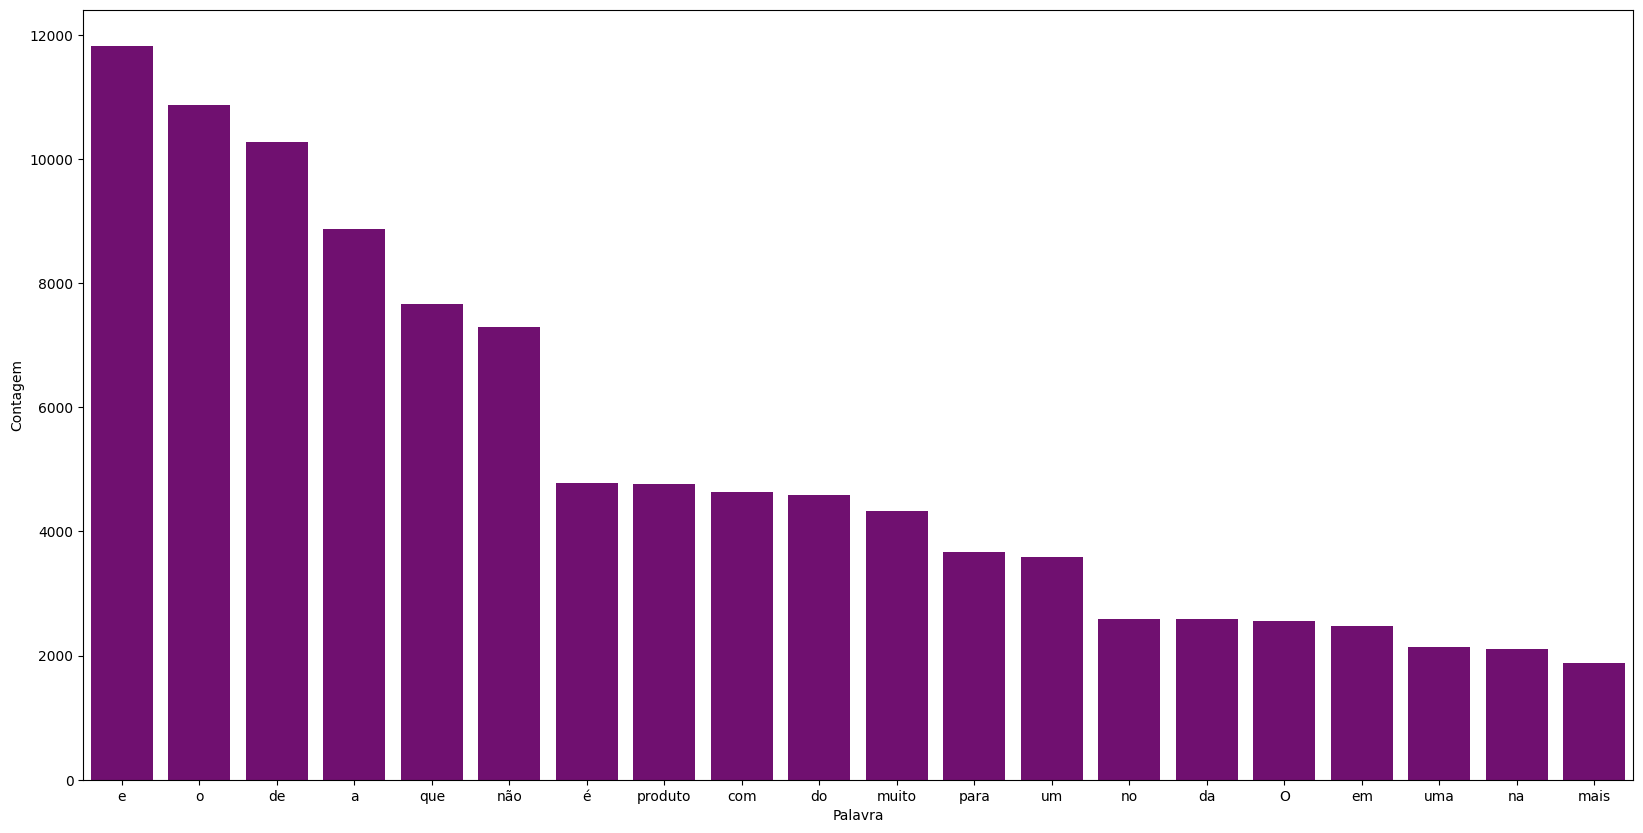

In [24]:
plt.figure(figsize=(20,10))
ax = sns.barplot(data=df_freq.nlargest(columns='Frequencia', n=20),
                 x = 'Palavra', y = 'Frequencia', color = 'purple')
ax.set(ylabel='Contagem')
plt.show()

## Remoção de stopwords

In [25]:
irrelevantes = nltk.corpus.stopwords.words('portuguese')
irrelevantes

['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as',
 'às',
 'até',
 'com',
 'como',
 'da',
 'das',
 'de',
 'dela',
 'delas',
 'dele',
 'deles',
 'depois',
 'do',
 'dos',
 'e',
 'é',
 'ela',
 'elas',
 'ele',
 'eles',
 'em',
 'entre',
 'era',
 'eram',
 'éramos',
 'essa',
 'essas',
 'esse',
 'esses',
 'esta',
 'está',
 'estamos',
 'estão',
 'estar',
 'estas',
 'estava',
 'estavam',
 'estávamos',
 'este',
 'esteja',
 'estejam',
 'estejamos',
 'estes',
 'esteve',
 'estive',
 'estivemos',
 'estiver',
 'estivera',
 'estiveram',
 'estivéramos',
 'estiverem',
 'estivermos',
 'estivesse',
 'estivessem',
 'estivéssemos',
 'estou',
 'eu',
 'foi',
 'fomos',
 'for',
 'fora',
 'foram',
 'fôramos',
 'forem',
 'formos',
 'fosse',
 'fossem',
 'fôssemos',
 'fui',
 'há',
 'haja',
 'hajam',
 'hajamos',
 'hão',
 'havemos',
 'haver',
 'hei',
 'houve',
 'houvemos',
 'houver',
 'houvera',
 'houverá',
 'houveram',
 'houvéramos',
 'houverão',
 'houverei',
 'houverem',
 'hou

In [26]:
frase_processada = []

for opiniao in df.avaliacao:
  palavras_texto = token_espaco.tokenize(opiniao)
  nova_frase = [palavra for palavra in palavras_texto if palavra not in irrelevantes]
  frase_processada.append(' '.join(nova_frase))

df['tratamento_1'] = frase_processada
df.head(7)

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo"
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe..."
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif..."
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo..."
5,13086,Comprei o produto e ñ tinha para entrega isso ...,1,negativo,Comprei produto ñ entrega legal!!!!!!
6,117549,"o produto pode até ser bom ,mais só posso aval...",1,negativo,"produto pode bom ,mais posso avalia-lo feito t..."


In [27]:
def classificar_texto(df, coluna_texto, coluna_classificacao):
    vetorizar = CountVectorizer(lowercase=False, max_features=50)
    bag_of_words = vetorizar.fit_transform(df[coluna_texto])
    X_treino, X_teste, y_treino, y_teste = train_test_split(bag_of_words,
                                                            df[coluna_classificacao],
                                                            random_state=4978)
    regressao_logistica = LogisticRegression()
    regressao_logistica.fit(X_treino, y_treino)
    acuracia = regressao_logistica.score(X_teste, y_teste)
    return print(f"Acurácia do modelo com '{coluna_texto}': {acuracia * 100:.3f}%")


classificar_texto(df, 'tratamento_1', 'sentimento')

Acurácia do modelo com 'tratamento_1': 81.089%


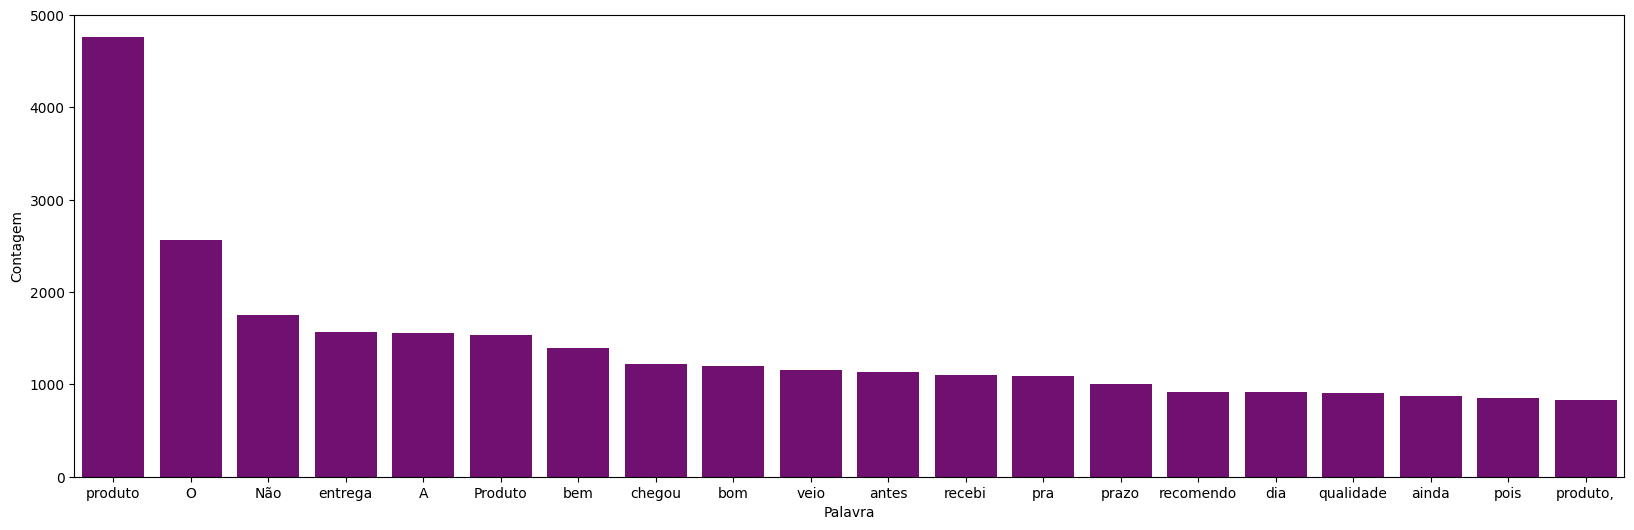

In [28]:
def grafico_frequencia(df, coluna_texto, quantidade):
    todas_palavras = ' '.join([texto for texto in df[coluna_texto]])
    token_espaco = tokenize.WhitespaceTokenizer()
    frequencia = nltk.FreqDist(token_espaco.tokenize(todas_palavras))
    df_frequencia = pd.DataFrame({"Palavra": list(frequencia.keys()),
                                  "Frequência": list(frequencia.values())})
    df_frequencia = df_frequencia.nlargest(columns="Frequência", n=quantidade)
    plt.figure(figsize=(20,6))
    ax = sns.barplot(data=df_frequencia, x="Palavra", y ="Frequência", color='purple')
    ax.set(ylabel="Contagem")
    plt.show()


grafico_frequencia(df, 'tratamento_1', 20)

## Remoção pontuação

### Exemplo remoção pontuação

In [29]:
frase = 'Esse é muito bom, recomendo'
token_pontuacao = tokenize.WordPunctTokenizer()
token_frase = token_pontuacao.tokenize(frase)
token_frase

['Esse', 'é', 'muito', 'bom', ',', 'recomendo']

In [30]:
frase_processada = []

for opiniao in df.avaliacao:
  palavras_texto = token_pontuacao.tokenize(opiniao)
  nova_frase = [palavra for palavra in palavras_texto if palavra.isalpha() and palavra not in irrelevantes]
  frase_processada.append(' '.join(nova_frase))

df['tratamento_2'] = frase_processada

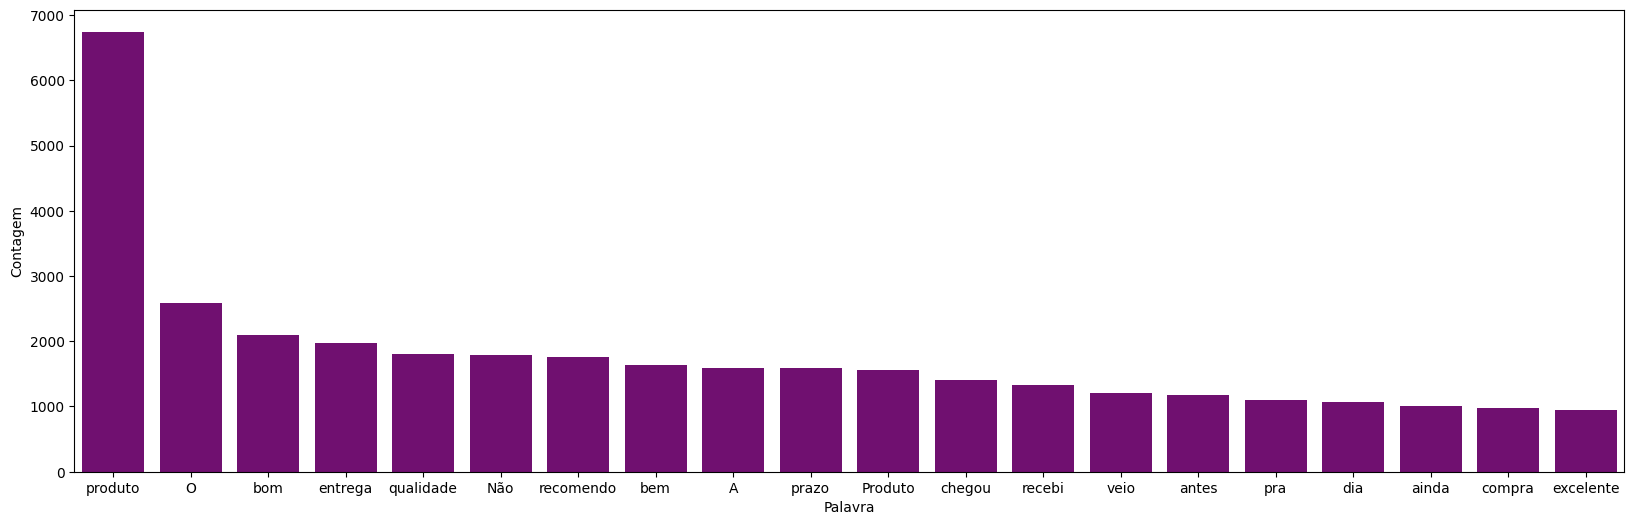

In [31]:
grafico_frequencia(df, 'tratamento_2', 20)

## Remoção acentuação e lowercase

### Exemplo remoção acentuação

In [32]:
frase = 'Um aparelho tem otima performance, marcas conhecidas e não é ruim'

frase = unidecode.unidecode(frase)
frase

'Um aparelho tem otima performance, marcas conhecidas e nao e ruim'

In [33]:
sem_acentos = [unidecode.unidecode(texto) for texto in df['tratamento_2']]

In [34]:
stopwords_sem_acento = [unidecode.unidecode(palavra) for palavra in irrelevantes]

In [35]:
df['tratamento_3'] = sem_acentos

frase_processada = []

for opiniao in df.tratamento_3:
  palavras_texto = token_pontuacao.tokenize(opiniao.lower())
  nova_frase = [palavra for palavra in palavras_texto if palavra not in stopwords_sem_acento]
  frase_processada.append(' '.join(nova_frase))

df['tratamento_3'] = frase_processada

df.head(7)

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2,tratamento_3
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo",Esse smartphone superou expectativas recomendo,smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe...",Eu fiz compra loja entregou produto compra fei...,fiz compra loja entregou produto compra feita ...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif...",Atendeu expectativas achei luz ruim nada dific...,atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo...",Gostei achei ficou desejar qualidade fotos Ach...,gostei achei ficou desejar qualidade fotos ach...
5,13086,Comprei o produto e ñ tinha para entrega isso ...,1,negativo,Comprei produto ñ entrega legal!!!!!!,Comprei produto ñ entrega legal,comprei produto n entrega legal
6,117549,"o produto pode até ser bom ,mais só posso aval...",1,negativo,"produto pode bom ,mais posso avalia-lo feito t...",produto pode bom posso avalia lo feito troca u...,produto pode bom posso avalia lo feito troca u...


In [36]:
classificar_texto(df, 'tratamento_3', 'sentimento')

Acurácia do modelo com 'tratamento_3': 83.746%


In [37]:
stemmer = nltk.RSLPStemmer()

stemmer.stem('comprei')

'compr'

In [38]:
stemmer.stem('comprado')

'compr'

In [39]:
frase_processada = []

for opiniao in df['tratamento_3']:
  palavras_texto = token_pontuacao.tokenize(opiniao)
  nova_frase = [stemmer.stem(palavra) for palavra in palavras_texto]
  frase_processada.append(' '.join(nova_frase))

df['tratamento_4'] = frase_processada

In [40]:
classificar_texto(df, 'tratamento_4', 'sentimento')

Acurácia do modelo com 'tratamento_4': 85.114%


### Exemplo importância palavras

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Exemplo
frases = ['comprei um otimo produto', 'comprei um produto pessimo']
tfidf = TfidfVectorizer(lowercase=False, max_features=50)
matriz = tfidf.fit_transform(frases)
pd.DataFrame(matriz.todense(), columns = tfidf.get_feature_names_out())

,comprei,otimo,pessimo,produto,um
0,0.448321,0.630099,0.000000,0.448321,0.448321
1,0.448321,0.000000,0.630099,0.448321,0.448321


In [42]:
tfidf_bruto = tfidf.fit_transform(df['avaliacao'])
X_train, X_test, y_train, y_test = train_test_split(tfidf_bruto, df['sentimento'], random_state=4978)

model.fit(X_train, y_train)
acc_tfidf_bruto = model.score(X_test, y_test)
print(f'Acc tfidf bruto: {acc_tfidf_bruto * 100:.3f}')

Acc tfidf bruto: 79.541


In [43]:
tfidf_tratados = tfidf.fit_transform(df['tratamento_4'])
X_train, X_test, y_train, y_test = train_test_split(tfidf_tratados,
                                                    df['sentimento'],
                                                    random_state=4978)

model.fit(X_train, y_train)
acc_tfidf_tratados = model.score(X_test, y_test)
print(f'Acc tfidf bruto: {acc_tfidf_tratados * 100:.3f}')

Acc tfidf bruto: 85.139


### Exemplo ngrams (bigrams)

In [44]:
from nltk import ngrams

frase = 'comprei um produto ruim'
frase_separada = token_espaco.tokenize(frase)
pares = ngrams(frase_separada, 2)
list(pares)

[('comprei', 'um'), ('um', 'produto'), ('produto', 'ruim')]

In [45]:
tfidf_50  = TfidfVectorizer(lowercase=False, max_features = 50,
                            ngram_range = (1,2))

vec_tfidf = tfidf_50.fit_transform(df['tratamento_4'])
X_train, X_test, y_train, y_test = train_test_split(vec_tfidf,
                                                    df['sentimento'],
                                                    random_state=4978)

model.fit(X_train, y_train)
acc_tfidf_ngrams = model.score(X_test, y_test)
print(f'Acc tfidf ngrams 50 features: {acc_tfidf_ngrams * 100:.3f}')

Acc tfidf ngrams 50 features: 85.217


In [46]:
tfidf  = TfidfVectorizer(lowercase=False,
                            ngram_range = (1,2))

vec_tfidf = tfidf.fit_transform(df['tratamento_4'])
X_train, X_test, y_train, y_test = train_test_split(vec_tfidf,
                                                    df['sentimento'],
                                                    random_state=4978)

model.fit(X_train, y_train)
acc_tfidf_ngrams = model.score(X_test, y_test)
print(f'Acc tfidf ngrams todas features: {acc_tfidf_ngrams * 100:.3f}')

Acc tfidf ngrams todas features: 91.847


In [47]:
tfidf_1000  = TfidfVectorizer(lowercase=False, max_features = 1000,
                            ngram_range = (1,2))

vec_tfidf = tfidf_1000.fit_transform(df['tratamento_4'])
X_train, X_test, y_train, y_test = train_test_split(vec_tfidf,
                                                    df['sentimento'],
                                                    random_state=4978)

model.fit(X_train, y_train)
acc_tfidf_ngrams = model.score(X_test, y_test)
print(f'Acc tfidf ngrams 1000 features: {acc_tfidf_ngrams * 100:.3f}')

Acc tfidf ngrams 1000 features: 91.847


In [48]:
vec_tfidf.shape

(15501, 1000)

In [49]:
pesos = pd.DataFrame(model.coef_[0].T, index = tfidf_1000.get_feature_names_out())
pesos.nlargest(20, 0)

,0
otim,7.781088
excel,7.430921
bom,5.996893
perfeit,5.086188
ador,5.050502
satisfeit,4.841244
rap,4.109015
lind,3.774459
ame,3.513963
maravilh,3.490755


In [50]:
pesos.nsmallest(20, 0)

,0
pess,-4.644158
ruim,-4.068716
receb,-4.062899
frac,-3.716810
horri,-3.379785
fragil,-3.038980
defeit,-3.036871
devolv,-2.935014
decepcion,-2.896531
dinh,-2.701120


In [51]:
import joblib

joblib.dump(tfidf_1000, 'tfidf_vectorizer.pkl')
joblib.dump(model, 'modelo_regressao_logistica.pkl')

['modelo_regressao_logistica.pkl']

In [52]:
tfidf = joblib.load('tfidf_vectorizer.pkl')
model = joblib.load('modelo_regressao_logistica.pkl')

### Automatizando classificação

In [53]:
palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')
token_pontuacao = tokenize.WordPunctTokenizer()
stemmer = nltk.RSLPStemmer()

def processar_avaliacao(avaliacao):
  #passo 1
  tokens = token_pontuacao.tokenize(avaliacao)
  #passo 2
  frase_processada = [palavra for palavra in tokens if palavra.lower() not in palavras_irrelevantes]
  #passo 3
  frase_processada = [palavra for palavra in frase_processada if palavra.isalpha()]
  #passo 4
  frase_processada = [unidecode.unidecode(palavra) for palavra in frase_processada]
  #passo 5
  frase_processada = [stemmer.stem(palavra) for palavra in frase_processada]
  return ' '.join(frase_processada)

In [54]:
avaliacoes_novas = ["Ótimo produto, super recomendo!",
                 "A entrega atrasou muito! Estou decepcionado com a compra",
                 "Muito satisfeito com a compra. Além de ter atendido as expectativas, o preço foi ótimo",
                 "Horrível!!! O produto chegou danificado e agora estou tentando fazer a devolução.",
                 '''Rastreando o pacote, achei que não fosse recebê-lo, pois, na data prevista, estava sendo entregue em outra cidade.
                 Mas, no fim, deu tudo certo e recebi o produto.Produto de ótima qualidade, atendendo bem as minhas necessidades e por
                 um preço super em conta.Recomendo.''']

avaliacoes_novas_processadas = [processar_avaliacao(avaliacao) for avaliacao in avaliacoes_novas]

In [55]:
avaliacoes_novas_processadas

['otim produt sup recom',
 'entreg atras decepcion compr',
 'satisfeit compr alem ter atend expect prec otim',
 'horri produt cheg danific agor tent faz devoluca',
 'rastre pacot ach receb lo poi dat prev send entreg outr cidad fim deu tud cert receb produt produt otim qual atend bem necess prec sup cont recom']

In [56]:
avaliacoes_novas_tfidf = tfidf.transform(avaliacoes_novas_processadas)

predicoes = model.predict(avaliacoes_novas_tfidf)

df_predicoes = pd.DataFrame({'avaliacao': avaliacoes_novas,
                             'sentimento previsto': predicoes})

df_predicoes

,avaliacao,sentimento previsto
0,"Ótimo produto, super recomendo!",positivo
1,A entrega atrasou muito! Estou decepcionado co...,negativo
2,Muito satisfeito com a compra. Além de ter ate...,positivo
3,Horrível!!! O produto chegou danificado e agor...,negativo
4,"Rastreando o pacote, achei que não fosse receb...",positivo


In [57]:
url = 'https://raw.githubusercontent.com/alura-cursos/nlp_analise_sentimento/refs/heads/main/Dados/novas_avaliacoes.csv'

df2 = pd.read_csv(url)
df2

,ID_avaliacao,avaliacao
0,8558,Até que o sabor é bom. Muito melhor que tomar ...
1,3553,"Nossa sério, absurdo, compro o produto com rec..."
2,5590,Bom custo benefício
3,6617,Saboroso e nutritivo. Tem me salvado nos dias ...
4,7987,"Fiquei decepcionada com a situação, a embalage..."
5,9102,Uma unidade do pacote veio furada e vazou em t...
6,4992,Comprei em junho mas o produto venceu em março
7,2127,"Gente, o meu chegou todo certinho, eu tava com..."
8,6697,"Gosto muito desse produto, ótima qualidade, e ..."
9,1986,Esse produto veio na quantidade que eu não ped...


In [62]:
coluna2_lista = df2.iloc[:, 1].tolist()

coluna2_lista

['Até que o sabor é bom. Muito melhor que tomar whey. Vale a pena para um lanche, ceia, dia corrido',
 'Nossa sério, absurdo, compro o produto com recorrência, dessa vez senti um gosto estranho e não reparei assim que comprei, mas ele está vencido, veio uma leva vencida desde MARÇO, sendo que foi entregue pra mim em julho.',
 'Bom custo benefício',
 'Saboroso e nutritivo. Tem me salvado nos dias de correria do trabalho, quando não dá para fazer um lanche. Me ajuda bastante com os treinos.',
 'Fiquei decepcionada com a situação, a embalagem chegou totalmente encharcada (deixaram a mercadoria na portaria do condomínio cheio de formiga e com a embalagem derretendo). De 12 unidades, 06 estavam estouradas e o resto derretendo pois a embalagem do produto é de papelão. Totalmente impróprio para o consumo!',
 'Uma unidade do pacote veio furada e vazou em toda minha geladeira',
 'Comprei em junho mas o produto venceu em março',
 'Gente, o meu chegou todo certinho, eu tava com medo de vir faltan

In [64]:
avaliacoes_novas_processadas = [processar_avaliacao(avaliacao) for avaliacao in coluna2_lista]

avaliacoes_novas_tfidf = tfidf.transform(avaliacoes_novas_processadas)

predicoes = model.predict(avaliacoes_novas_tfidf)

df2_predicoes = pd.DataFrame({'avaliacao': coluna2_lista,
                             'sentimento previsto': predicoes})

df2_predicoes

,avaliacao,sentimento previsto
0,Até que o sabor é bom. Muito melhor que tomar ...,positivo
1,"Nossa sério, absurdo, compro o produto com rec...",negativo
2,Bom custo benefício,positivo
3,Saboroso e nutritivo. Tem me salvado nos dias ...,positivo
4,"Fiquei decepcionada com a situação, a embalage...",negativo
5,Uma unidade do pacote veio furada e vazou em t...,negativo
6,Comprei em junho mas o produto venceu em março,negativo
7,"Gente, o meu chegou todo certinho, eu tava com...",positivo
8,"Gosto muito desse produto, ótima qualidade, e ...",positivo
9,Esse produto veio na quantidade que eu não ped...,negativo


## Pontos importantes

* Explorar dados textuais;
* Utilizar a técnica de Bag of words para converter textos em vetores numéricos;
* Separar os dados em treino e teste;
* Treinar o modelo de regressão logística;
* Obter a acurácia do modelo nos dados de teste;
* Utilizar a biblioteca wordcloud para criar nuvens de palavras;
* Criar uma função para filtrar os sentimentos;
* Aplicar a tokenização com a biblioteca NLTK;
* Calcular a frequência das palavras com a biblioteca NLTK;
* Criar um gráfico com as palavras mais frequentes;
* Importar uma lista de stopwords com a biblioteca NLTK;
* Realizar a tokenização por pontuação;
* Realizar o tratamento para remover a pontuação de um texto;
* Remover acentos com a biblioteca unidecode;
* Transformar todos os caracteres em minúsculo;
* Evitar flexões e derivações de palavras com a técnica stemming;
* Criar um vetor TF-IDF com a biblioteca scikit-learn;
* Utilizar N-grams para capturar o contexto nas sequências de palavras;
* Salvar o modelo TF-IDF e o modelo de regressão logística treinados;
* Carregar o TF-IDF e o modelo de regressão logística;
* Criar uma função para processar novas avaliações;
* Aplicar o TF-IDF e o modelo de regressão logística aos dados novos;
* Obter um DataFrame com as classificações dos sentimentos.
